## Algerian Forest Fires Dataset 
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("Algerian_forest_fires_dataset_UPDATE.xlsx")

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,4,6,2012,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire
4,5,6,2012,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire


In [4]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

## Data Cleaning

In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [6]:
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [7]:
df["Classes"].unique()

array(['not fire   ', 'fire   ', 'not fire     ', 'not fire    '],
      dtype=object)

In [8]:
df["Classes"]=df["Classes"].str.strip()
df["Classes"].unique()

array(['not fire', 'fire'], dtype=object)

## Exploratory Data Analysis

In [9]:
df_copy=df.drop(columns=["day","month","year"])

In [10]:
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire
...,...,...,...,...,...,...,...,...,...,...,...
117,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire
118,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire
119,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
120,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [11]:
class_counts=df_copy["Classes"]=np.where(df_copy["Classes"]=="not fire",0,1)

In [12]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,0
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,0
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,0
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,0
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,0


In [13]:
df_copy["Classes"].value_counts()

Classes
1    79
0    43
Name: count, dtype: int64

In [14]:
import seaborn as sns

<Axes: ylabel='FWI'>

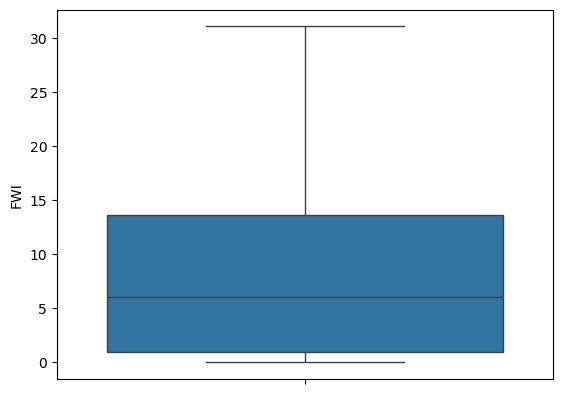

In [15]:
sns.boxplot(df["FWI"])

<Axes: xlabel='month', ylabel='count'>

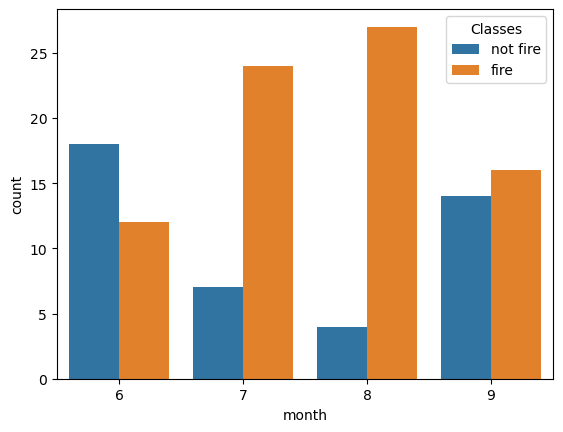

In [16]:
sns.countplot(x="month",hue="Classes",data=df)

## Feature Selection

In [17]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,4,6,2012,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire
4,5,6,2012,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire


In [18]:
df.drop(columns=["day","month","year"],axis=1,inplace=True)

In [19]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire


In [20]:
df["Classes"]=np.where(df["Classes"]=='not fire',0,1)

In [21]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,0
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,0
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,0
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,0
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,0


In [22]:
df["Classes"].value_counts()

Classes
1    79
0    43
Name: count, dtype: int64

In [23]:
X=df.drop(columns=["FWI"])
y=df["FWI"]

In [24]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,0
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0
...,...,...,...,...,...,...,...,...,...,...
117,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1
118,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0
119,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0
120,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0


In [25]:
y

0      0.2
1      0.2
2      0.1
3      1.0
4      0.9
      ... 
117    6.5
118    0.0
119    0.2
120    0.7
121    0.5
Name: FWI, Length: 122, dtype: float64

In [26]:
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
Temperature,1.000000,-0.598309,-0.258208,-0.129718,0.573122,0.389748,0.284506,0.538246,0.367756,0.500590,0.501757
RH,-0.598309,1.000000,0.141436,0.149027,-0.645540,-0.379057,-0.265698,-0.692335,-0.360802,-0.604374,-0.444215
Ws,-0.258208,0.141436,1.000000,-0.139740,-0.019406,0.028765,0.017140,0.133713,0.029740,0.107695,0.053450
Rain,-0.129718,0.149027,-0.139740,1.000000,-0.510498,-0.348431,-0.344823,-0.413477,-0.358060,-0.410564,-0.475288
FFMC,0.573122,-0.645540,-0.019406,-0.510498,1.000000,0.581300,0.480658,0.753370,0.577025,0.719442,0.796266
DMC,0.389748,-0.379057,0.028765,-0.348431,0.581300,1.000000,0.882122,0.627900,0.987917,0.851033,0.533712
DC,0.284506,-0.265698,0.017140,-0.344823,0.480658,0.882122,1.000000,0.468275,0.927528,0.713884,0.458389
ISI,0.538246,-0.692335,0.133713,-0.413477,0.753370,0.627900,0.468275,1.000000,0.608683,0.915852,0.697385
BUI,0.367756,-0.360802,0.029740,-0.358060,0.577025,0.987917,0.927528,0.608683,1.000000,0.843238,0.544863
FWI,0.500590,-0.604374,0.107695,-0.410564,0.719442,0.851033,0.713884,0.915852,0.843238,1.000000,0.683801


In [27]:
from sklearn.model_selection import train_test_split
X_Train,X_Test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [28]:
X_Train.shape,X_Test.shape

((91, 10), (31, 10))

In [29]:
#Feature selection using correlation
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [30]:
corr_features=correlation(X_Train,0.85)

In [31]:
X_Train.drop(corr_features,axis=1,inplace=True)
X_Test.drop(corr_features,axis=1,inplace=True)

In [ ]:
X_Train.shape,X_Test.shape

((91, 8), (31, 8))

In [33]:
#Standardize the data 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_Train=scaler.fit_transform(X_Train)
X_Test=scaler.transform(X_Test)

In [34]:
X_Train

array([[-1.19400663e+00,  2.03185067e+00,  2.00396174e-02,
        -1.89496944e-01, -2.71089288e+00, -9.81944982e-01,
        -1.19278904e+00, -1.39121669e+00],
       [ 1.54979649e+00, -2.19952767e+00,  9.31842209e-01,
        -1.89496944e-01,  9.32783179e-01,  1.51234651e-02,
         1.88148008e+00,  7.18795288e-01],
       [-9.64853846e-02,  2.36720467e-01,  4.75940913e-01,
         6.22435217e-02, -5.69434145e-01, -7.85339936e-01,
        -9.11483368e-01, -1.39121669e+00],
       [-1.46838695e+00,  9.41950191e-01,  2.00396174e-02,
        -4.41237410e-01, -1.13974637e-01, -3.07870539e-01,
        -7.50737271e-01, -1.39121669e+00],
       [-9.19626322e-01,  2.36720467e-01,  1.84364480e+00,
        -4.41237410e-01,  6.21152990e-01,  6.75154691e-01,
         7.36164135e-01,  7.18795288e-01],
       [ 7.26655552e-01, -7.89068223e-01,  4.75940913e-01,
        -4.41237410e-01,  7.88953861e-01,  1.96010910e+00,
         1.07774959e+00,  7.18795288e-01],
       [-1.46838695e+00,  1.726086

## Linear Regression


In [35]:
from sklearn.linear_model import LinearRegression
lin_regression=LinearRegression()
lin_regression.fit(X_Train,y_train)

LinearRegression()

In [36]:
y_pred=lin_regression.predict(X_Test)

In [37]:
#Performance measures
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

MSE:  1.0208049815415543
MAE:  0.7312986403618761
RMSE:  1.0103489404861838


In [38]:
#Model accuracy
from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

Model Accurracy:  0.9708907435145745


## Lasso Regression

In [39]:
from sklearn.linear_model import Lasso
lasso_regression=Lasso()
lasso_regression.fit(X_Train,y_train)
y_pred=lasso_regression.predict(X_Test)

In [40]:
#Performance measures
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

MSE:  1.993602962453629
MAE:  1.1541788941025546
RMSE:  1.411950056642808


In [41]:
from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

Model Accurracy:  0.9431504537952684


## Ridge Regression

In [42]:
from sklearn.linear_model import Ridge
ridge_regression=Ridge()
ridge_regression.fit(X_Train,y_train)
y_pred=ridge_regression.predict(X_Test)
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)


MSE:  1.033808172458902
MAE:  0.7451106729172158
RMSE:  1.0167635774647428
Model Accurracy:  0.9705199447563528


## ElasticNet Regression

In [43]:
from sklearn.linear_model import ElasticNet
el_regression=Ridge()
el_regression.fit(X_Train,y_train)
y_pred=el_regression.predict(X_Test)

In [44]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

MSE:  1.033808172458902
MAE:  0.7451106729172158
RMSE:  1.0167635774647428


In [45]:
from sklearn.metrics import r2_score
model_accuracy=r2_score(y_test,y_pred)
print("Model Accurracy: ",model_accuracy)

Model Accurracy:  0.9705199447563528


## Lasso Cross Validation

In [46]:
from sklearn.linear_model import LassoCV
lasscv=LassoCV(cv=5)
lasscv.fit(X_Train,y_train)

LassoCV(cv=5)

In [47]:
lasscv.alpha_

np.float64(0.19470511046800817)

In [49]:
lasscv.alphas_

array([7.86027891, 7.33052242, 6.83646974, 6.37571456, 5.94601274,
       5.54527138, 5.17153865, 4.82299426, 4.49794058, 4.19479444,
       3.91207934, 3.64841828, 3.4025271 , 3.17320816, 2.95934455,
       2.75989463, 2.57388697, 2.40041561, 2.23863563, 2.08775908,
       1.9470511 , 1.81582638, 1.69344576, 1.57931318, 1.47287276,
       1.37360606, 1.28102961, 1.1946925 , 1.11417423, 1.03908261,
       0.96905192, 0.90374107, 0.84283194, 0.78602789, 0.73305224,
       0.68364697, 0.63757146, 0.59460127, 0.55452714, 0.51715387,
       0.48229943, 0.44979406, 0.41947944, 0.39120793, 0.36484183,
       0.34025271, 0.31732082, 0.29593446, 0.27598946, 0.2573887 ,
       0.24004156, 0.22386356, 0.20877591, 0.19470511, 0.18158264,
       0.16934458, 0.15793132, 0.14728728, 0.13736061, 0.12810296,
       0.11946925, 0.11141742, 0.10390826, 0.09690519, 0.09037411,
       0.08428319, 0.07860279, 0.07330522, 0.0683647 , 0.06375715,
       0.05946013, 0.05545271, 0.05171539, 0.04822994, 0.04497

In [50]:
lasscv.mse_path_

array([[ 62.71121026,  58.51147306, 110.40839484,  29.87061908,
        100.55183034],
       [ 58.41124725,  52.56614073, 110.40839484,  26.05969783,
         95.79828367],
       [ 51.13805338,  47.34446292, 108.03133794,  22.75733957,
         87.60819581],
       [ 44.41292414,  41.61389203,  96.24591317,  19.89649756,
         80.37120424],
       [ 38.66212562,  36.45696762,  84.96935097,  17.41888735,
         73.97082824],
       [ 33.75214342,  31.961399  ,  75.09727023,  15.27389365,
         68.30524251],
       [ 29.56737063,  28.04176541,  66.45140326,  13.41750261,
         63.28540306],
       [ 26.00737588,  24.62337838,  58.87590831,  11.81150929,
         58.83341489],
       [ 22.98551164,  21.64219559,  52.23512643,  10.42271946,
         54.8811101 ],
       [ 20.42666904,  19.04151411,  46.41057844,   9.22230155,
         50.30835892],
       [ 18.26586032,  16.77229888,  41.29969289,   8.18528709,
         43.87507709],
       [ 16.44688237,  14.7918664 ,  36.812

Mean absolute error 0.7989538368242807
R2 Score 0.9672626400401381


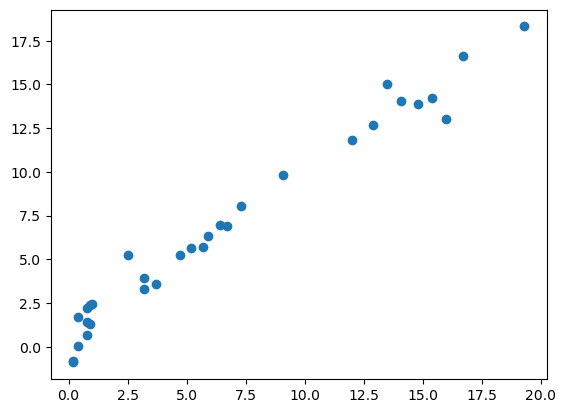

In [53]:

y_pred=lasscv.predict(X_Test)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Ridge Regression Cross Validation

In [54]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV()
ridgecv.fit(X_Train,y_train)


RidgeCV()

Mean absolute error 0.7451106729174497
R2 Score 0.9705199447563861


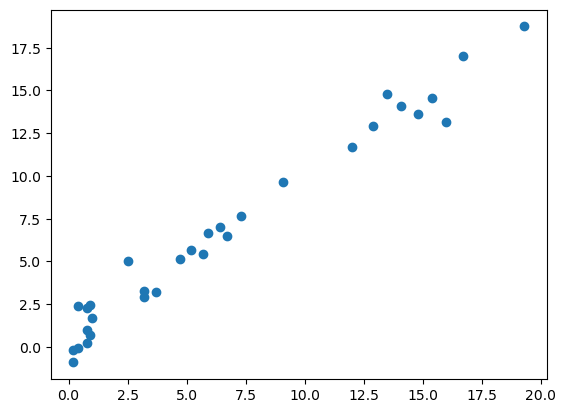

In [55]:
y_pred=ridgecv.predict(X_Test)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)